In [11]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import re

matplotlib.rc('font', family = 'Malgun Gothic')

In [22]:
df_merged_total = pd.read_csv("data/merged_data_total.csv")
df_merged_back = pd.read_csv("data/merged_data_backend.csv")
df_merged_front = pd.read_csv("data/merged_data_frontend.csv")

df_merged_total.head()

,company_name,position,skill
0,사이버다임,서버개발팀 모바일 개발자(경력),"Android Studio, Node.js, Webpack, Redux, React..."
1,사이버다임,서버개발팀 웹클라이언트 개발자(경력),"JavaScript, CSS 3, HTML5"
2,콘센트릭스서비스코리아,[Catalyst] 커머스플랫폼 구축/운영 BA,"SAP, hybris-commerce, Shopify, Spring Boot, Do..."
3,바로팜,안드로이드 개발자 (Android Developer),"Kotlin, Java"
4,블록체인글로벌,토큰증권 서비스 프론트엔드 개발(미들급),"JavaScript, Vue.js, React, TypeScript, Git"


In [13]:
#df_merged에서 position에 해당하는 키값에 따라 새로운 dataframe으로 분류류
full_key = ['풀스택','풀 스택', 'full stack', 'fullstack']

def contains_keyword(text, keywords):
    text = str(text).lower()
    return any(kw.lower() in text for kw in keywords)


df_merged_full  = df_merged_total[df_merged_total['position'].apply(lambda x: contains_keyword(x, full_key))].copy()

In [14]:
def draw_bar(data, df_name):
    figure, ax = plt.subplots()
    figure.set_size_inches(18,10)

    #위에 만든 df의 column 하나씩 그래프로 그리기
    colors = sns.color_palette("hls", len(data.index))
    ax = sns.barplot(x = data.values, y = data.index, hue = data.index, palette = colors, ax = ax, )
    ax.set_title(df_name, fontsize=20)
    ax.set_ylabel('')
    ax.legend(data.index, ncol=2, loc='lower right', labelcolor=colors, fontsize=14)

    #각 bar 위에 해당하는 숫자를 넣기기
    max_value = max(data.values)
    for j, (x_val, y_val) in enumerate(zip(data.index, data.values)):
        ax.text(x = y_val + max_value*0.02, y = j, s = f'{y_val:.0f}', ha = 'center', va = 'center', fontsize = 12, color = colors[j])
    plt.show()

In [15]:
def autopct_func(pct):
    return ('%.1f%%' % pct) if pct > 2 else ''

def draw_circle(data, df_name):
    figure, ax = plt.subplots()
    figure.set_size_inches(20,10)

    colors = sns.color_palette("hls", len(data.index))

    # 원형 그래프 그리기 autopct=비율 표시, pctdistance=중앙으로부터 pct거리, startangle=시작 각도
    autotexts = ax.pie(data.values, colors=colors, autopct=autopct_func, pctdistance=0.8,\
                startangle=90, rotatelabels=True, textprops={'fontsize': 14})
    
    ax.legend(data.index, ncol=2, loc='right', labelcolor=colors, fontsize=14)
    ax.set_title(df_name, fontsize=20, x=0.1, y=0.95)
    ax.axis('equal')  # 원이 찌그러지지 않게 1:1비율 고정정

    plt.show()

In [16]:
keys = ['AMAZONEC2', 'ANGULAR2', 'AWS', 'C#', 'C++', 'C언어', 
       'CSS3', 'DOCKER', 'EXPRESSJS', 'FLUTTER', 'GIT', 'GRADLE', 'GRAPHQL',
       'HTML5', 'IONIC', 'JAVA', 'JAVASCRIPT', 'KOTLIN', 'MARIADB', 'MSA',
       'MYBATIS', 'MYSQL', 'NEST', 'NEXT', 'NODE', 'PHP', 'PYTHON', 'RDB', 'REACT',
       'RECOIL', 'REDUX', 'RESTAPI', 'RXJS', 'SPRING', 'SQL', 'SWAGGERUI',
       'TYPESCRIPT', 'UBUNTU', 'VUE', 'ZUSTAND']

def data_frac(df, series):
    series = series.rename(index=lambda x: re.sub(r'\bC\s?(?:언어|개발)', 'C언어', x, flags=re.IGNORECASE))

    for keyword in keys:
        count = df['skill'].fillna('').str.contains(re.escape(keyword), flags=re.IGNORECASE).sum()
        series[keyword] += count

    series = series.drop(series[series == 0].index).sort_values(ascending=False)
    return series

In [18]:
#position을 구분하지 않고 전체 detail데이터에서 키워드 세기
df_merged_cnt = pd.Series(0, index=keys)
df_merged_cnt = data_frac(df_merged_total,df_merged_cnt)

#각 position별로 구분하여 detail데이터에서 키워드 세기
df_merged_back_cnt = pd.Series(0, index=keys)
df_merged_back_cnt = data_frac(df_merged_back, df_merged_back_cnt)

df_merged_front_cnt = pd.Series(0, index=keys)
df_merged_front_cnt = data_frac(df_merged_front, df_merged_front_cnt)

df_merged_full_cnt = pd.Series(0, index=keys)
df_merged_full_cnt = data_frac(df_merged_full, df_merged_full_cnt)

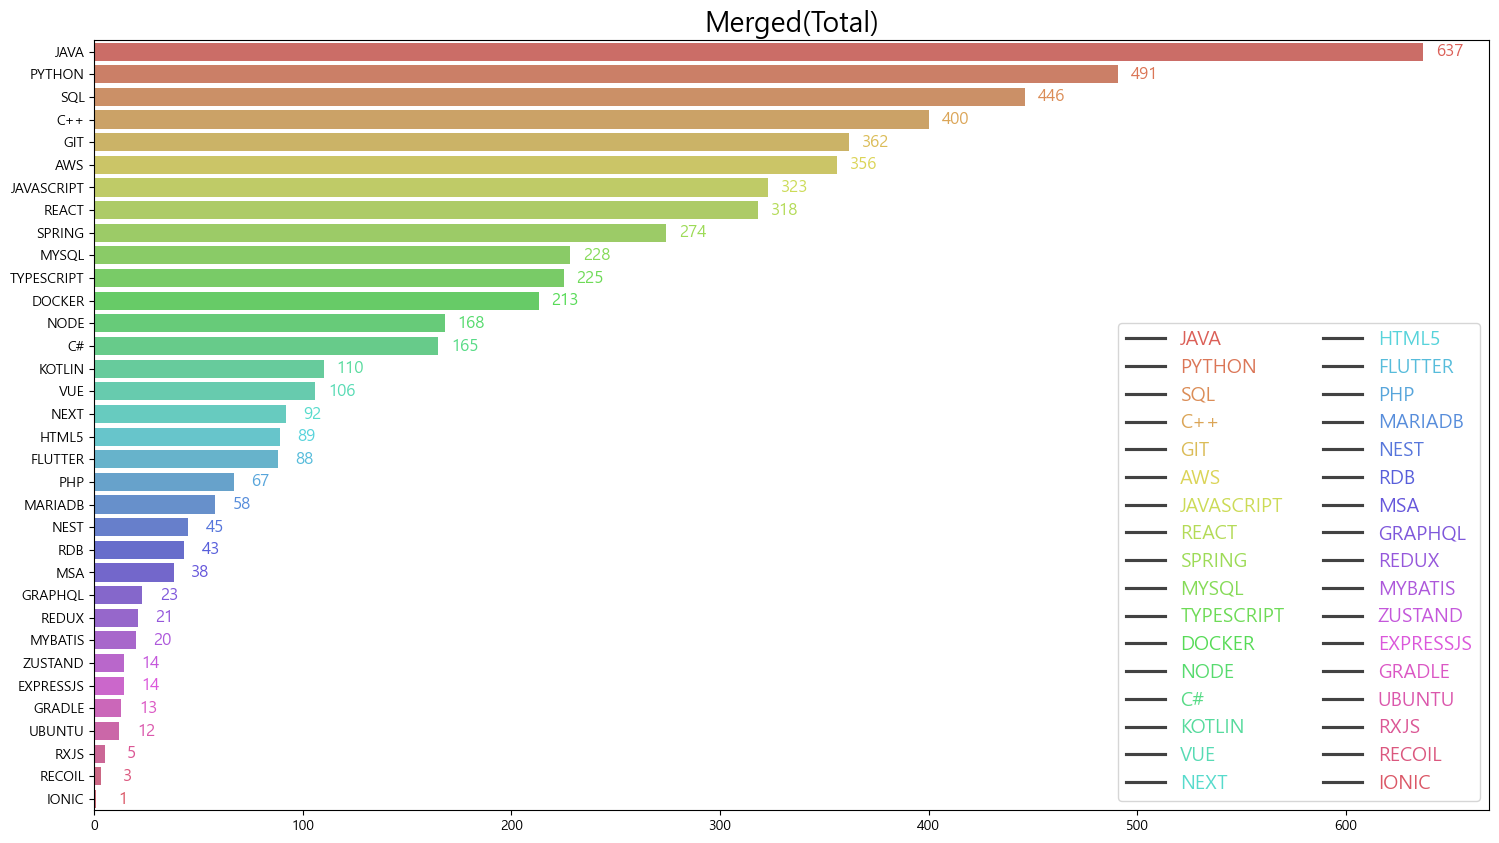

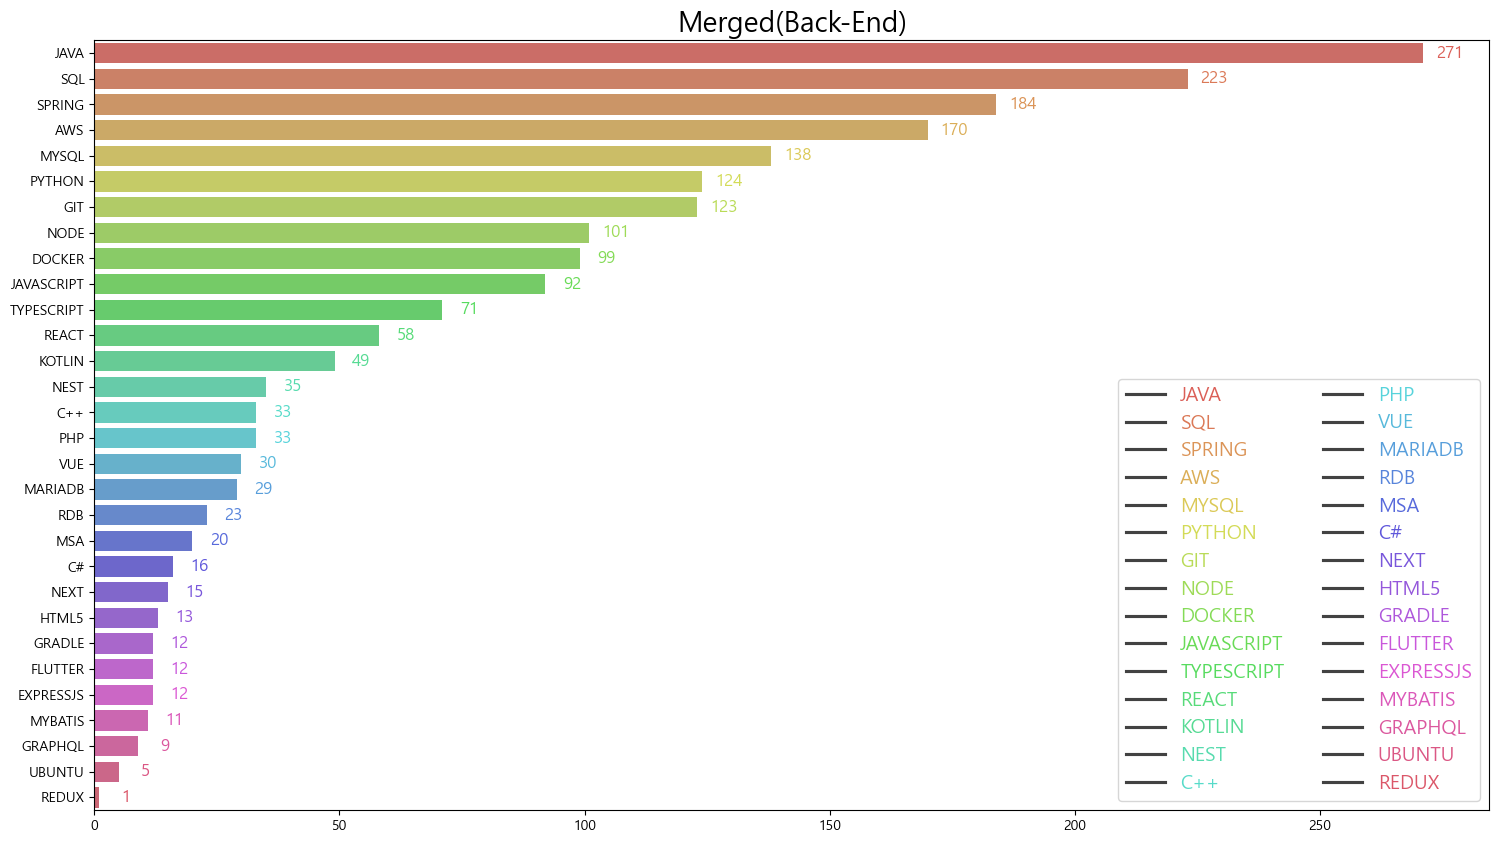

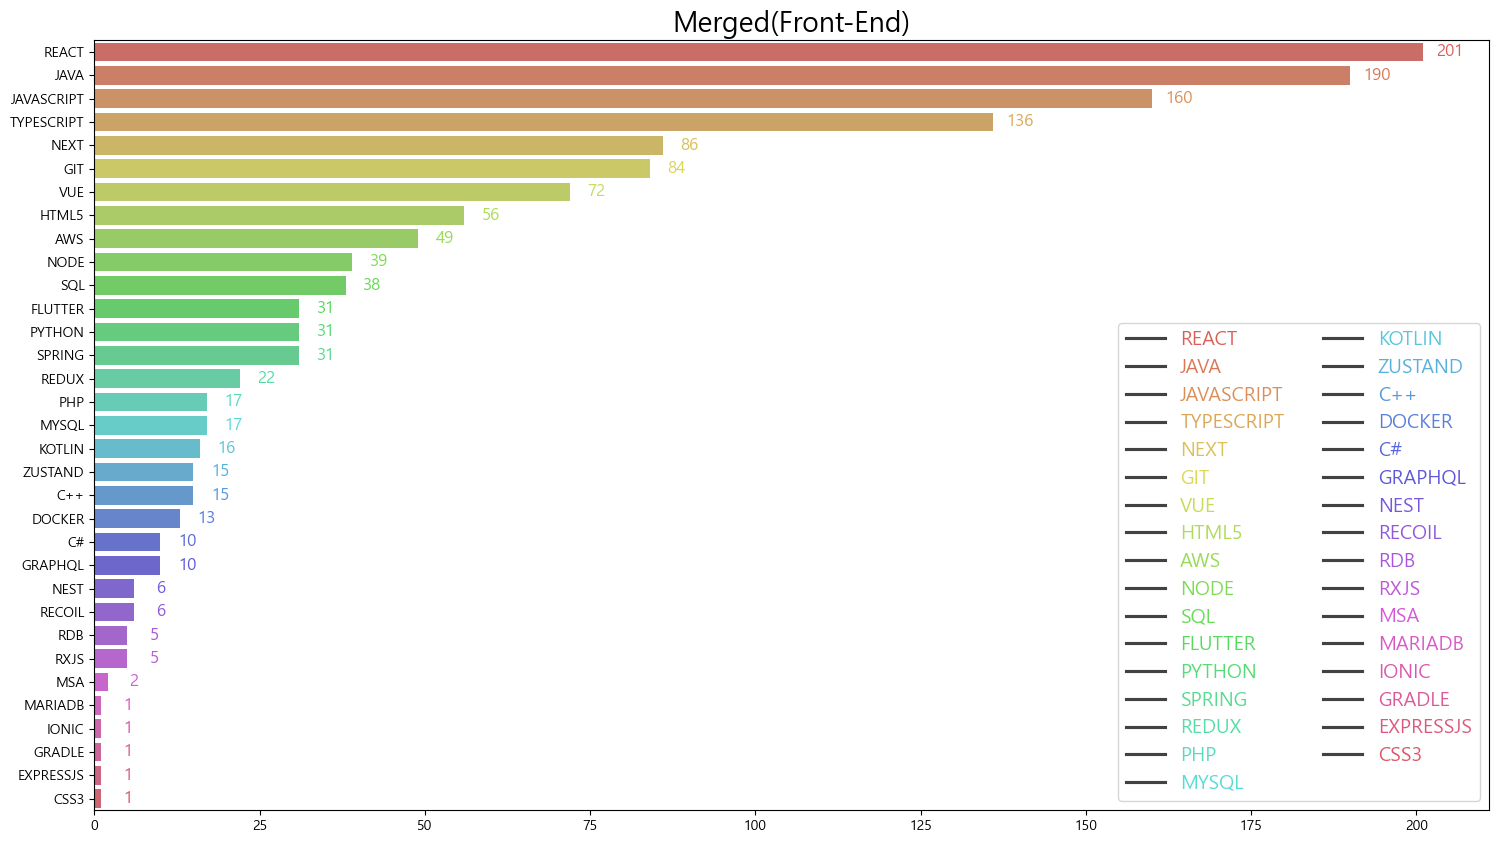

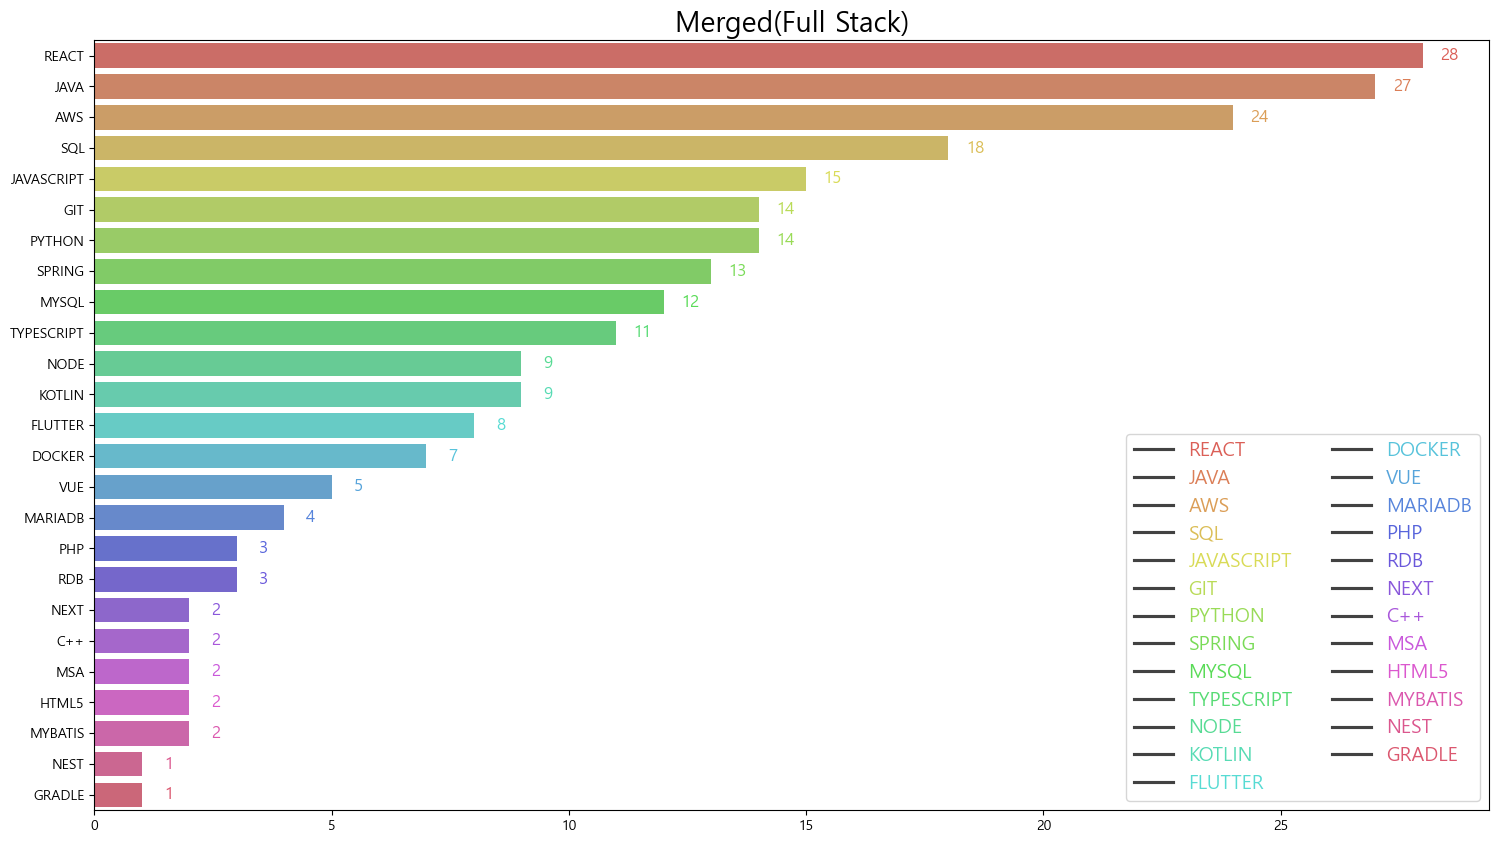

In [19]:
draw_bar(df_merged_cnt, 'Merged(Total)')
draw_bar(df_merged_back_cnt, 'Merged(Back-End)')
draw_bar(df_merged_front_cnt, 'Merged(Front-End)')
draw_bar(df_merged_full_cnt, 'Merged(Full Stack)')

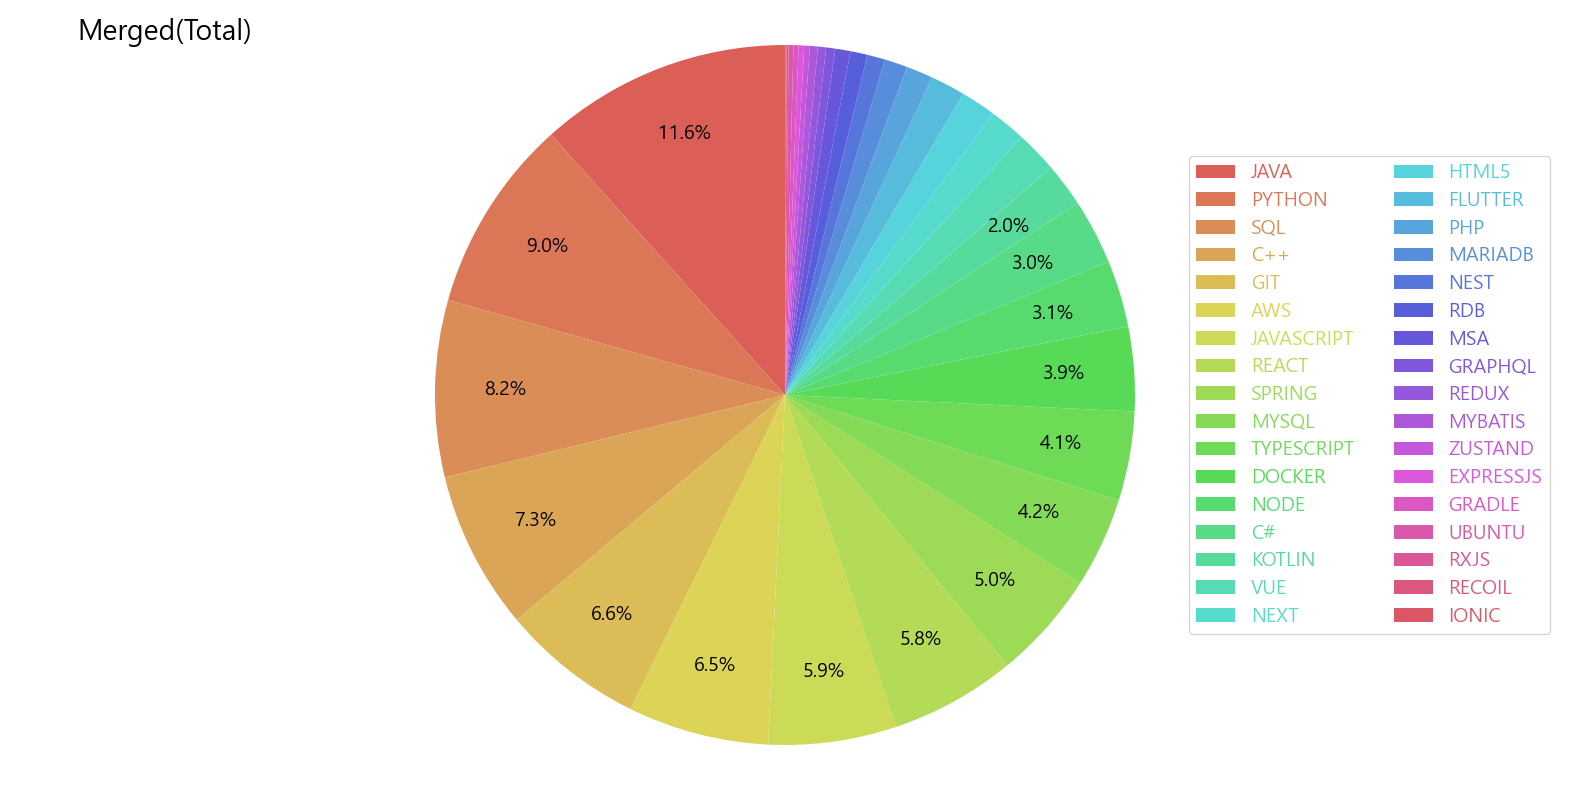

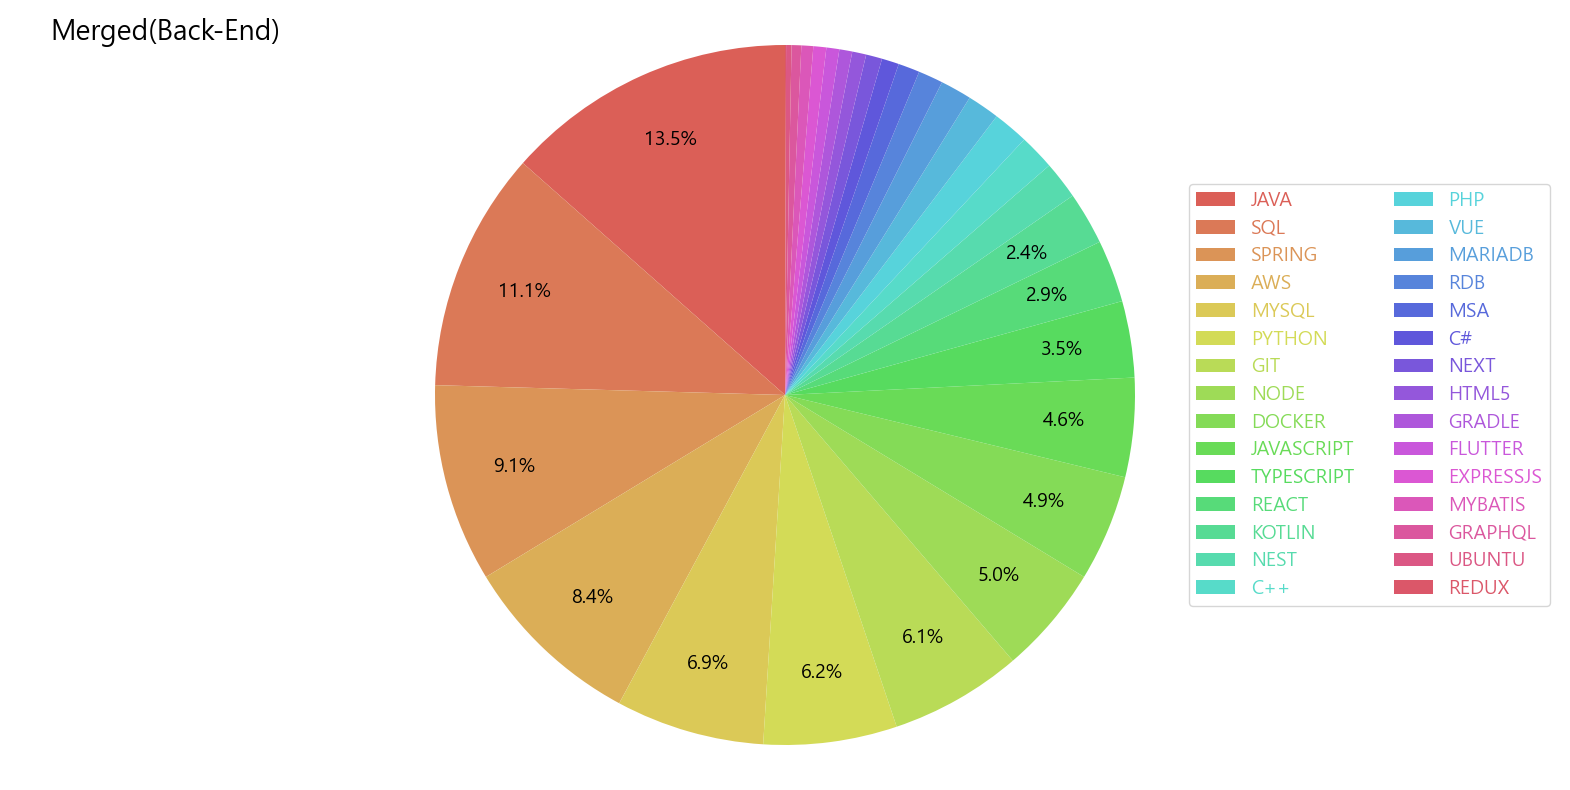

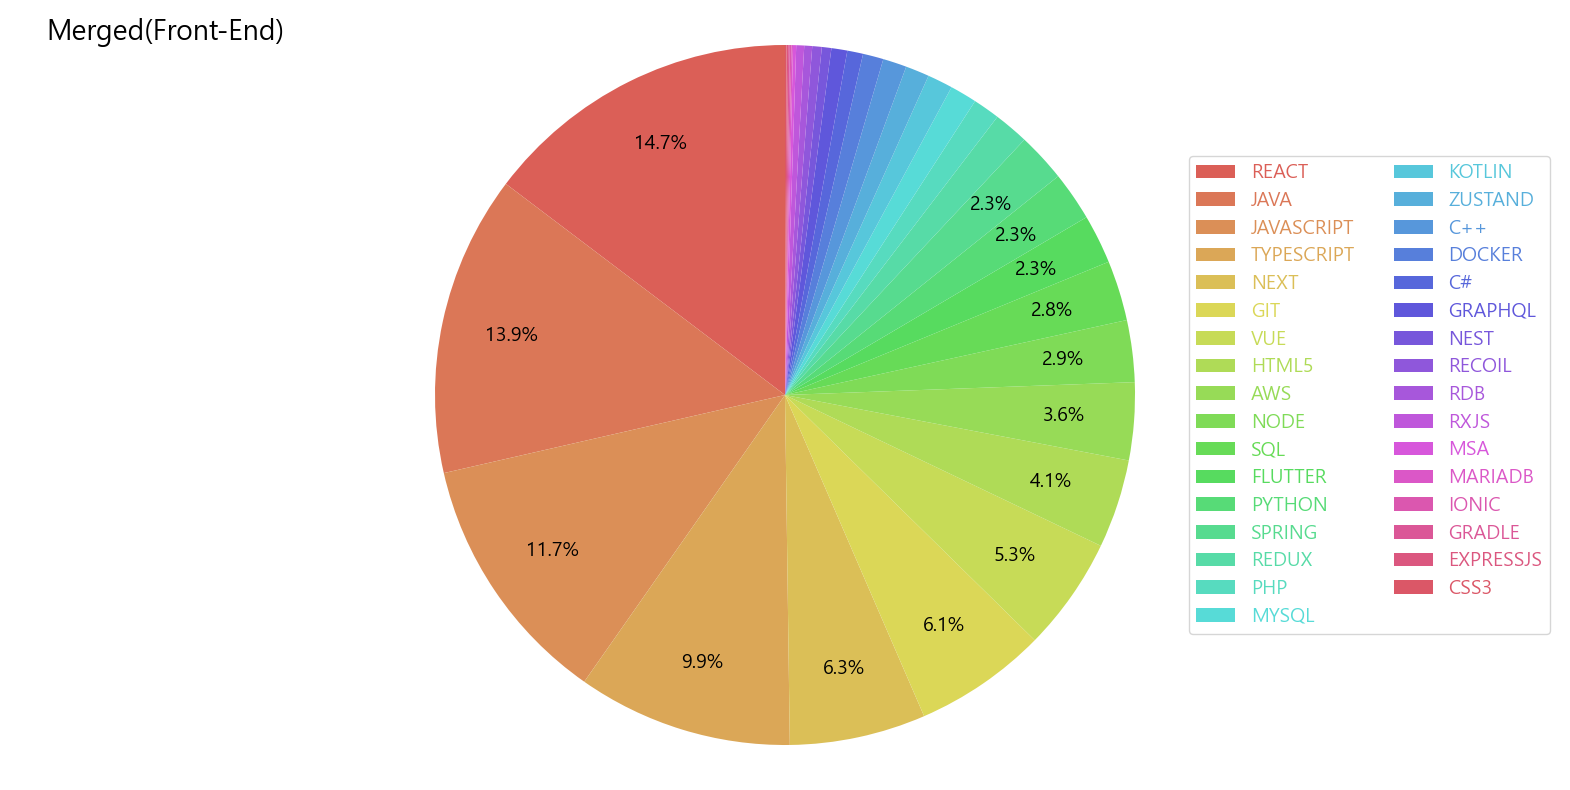

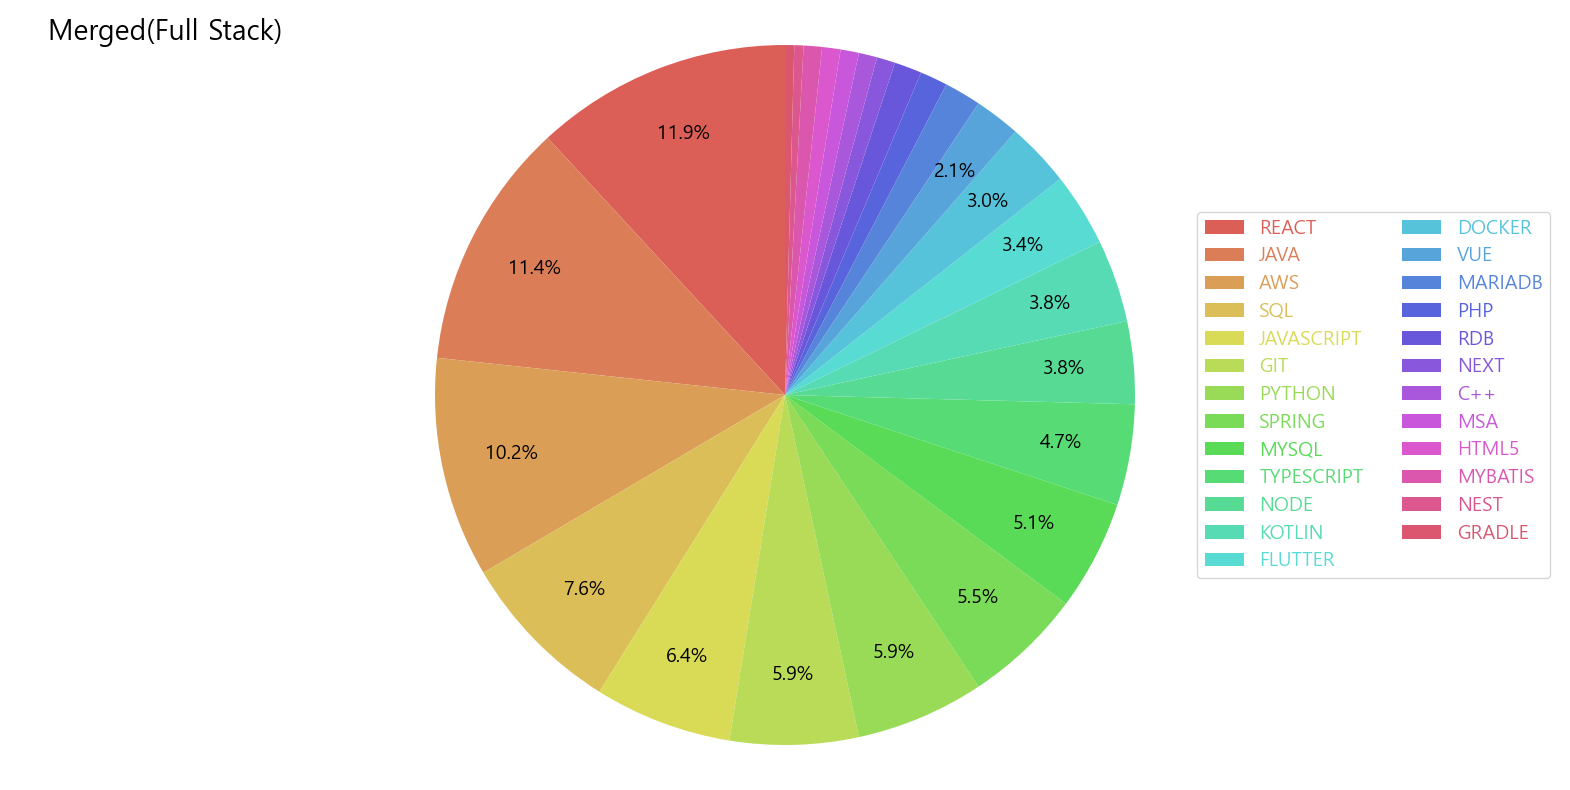

In [21]:
draw_circle(df_merged_cnt, 'Merged(Total)')
draw_circle(df_merged_back_cnt, 'Merged(Back-End)')
draw_circle(df_merged_front_cnt, 'Merged(Front-End)')
draw_circle(df_merged_full_cnt, 'Merged(Full Stack)')